In [1]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import esda
from libpysal import weights
from splot.esda import lisa_cluster
import statsmodels.api as sm
import matplotlib as mpl
import json

In [2]:
with open("../scripts/08_plot_delays_politics.json", "r") as f:
    plot_params = json.load(f)
for key in plot_params["rcparams"]:
    mpl.rcParams[key] = plot_params["rcparams"][key]

In [3]:
G = ox.load_graphml(
    "../data/processed/paris_simplified_results/paris_cleaned_multigraph.graphml"
)
gdf_edges = ox.graph_to_gdfs(G, edges=True, nodes=False)
gdf_edges = gdf_edges[["geometry", "length", "built"]]

In [4]:
gdf_iris = gpd.read_file(
    "../data/processed/paris_official_data/paris_dem_iris_condensed_enriched.gpkg"
)

In [5]:
gdf_iris = gdf_iris.to_crs(gdf_edges.crs)

In [6]:
BUSINESSES_TO_COUNT = [
    "Alimentaire",
    "Grand magasin",
    "Hôtel",
    "Non Alimentaire",
    "Restauration",
    "Service commercial",
]

In [7]:
gdf_iris.drop(
    ["CODE_IRIS", "geometry", "population", "active_population", "poverty_rate"]
    + BUSINESSES_TO_COUNT
    + [bus + "_density" for bus in BUSINESSES_TO_COUNT],
    axis=1,
).corr()

,pop_density,median_income,commuter_cyclist_share,commuter_driver_share,LUD_share,LUG_share
pop_density,1.000000,-0.280120,0.081091,-0.155952,-0.163286,0.348464
median_income,-0.280120,1.000000,0.009482,0.269896,0.536528,-0.457109
commuter_cyclist_share,0.081091,0.009482,1.000000,-0.263286,-0.210663,0.278606
commuter_driver_share,-0.155952,0.269896,-0.263286,1.000000,0.186023,-0.688710
LUD_share,-0.163286,0.536528,-0.210663,0.186023,1.000000,-0.299089
LUG_share,0.348464,-0.457109,0.278606,-0.688710,-0.299089,1.000000


In [8]:
gdf_vote_sta = gpd.read_file(
    "../data/processed/paris_official_data/paris_vote_list.gpkg"
)
gdf_vote_sta = gdf_vote_sta.to_crs(gdf_edges.crs)

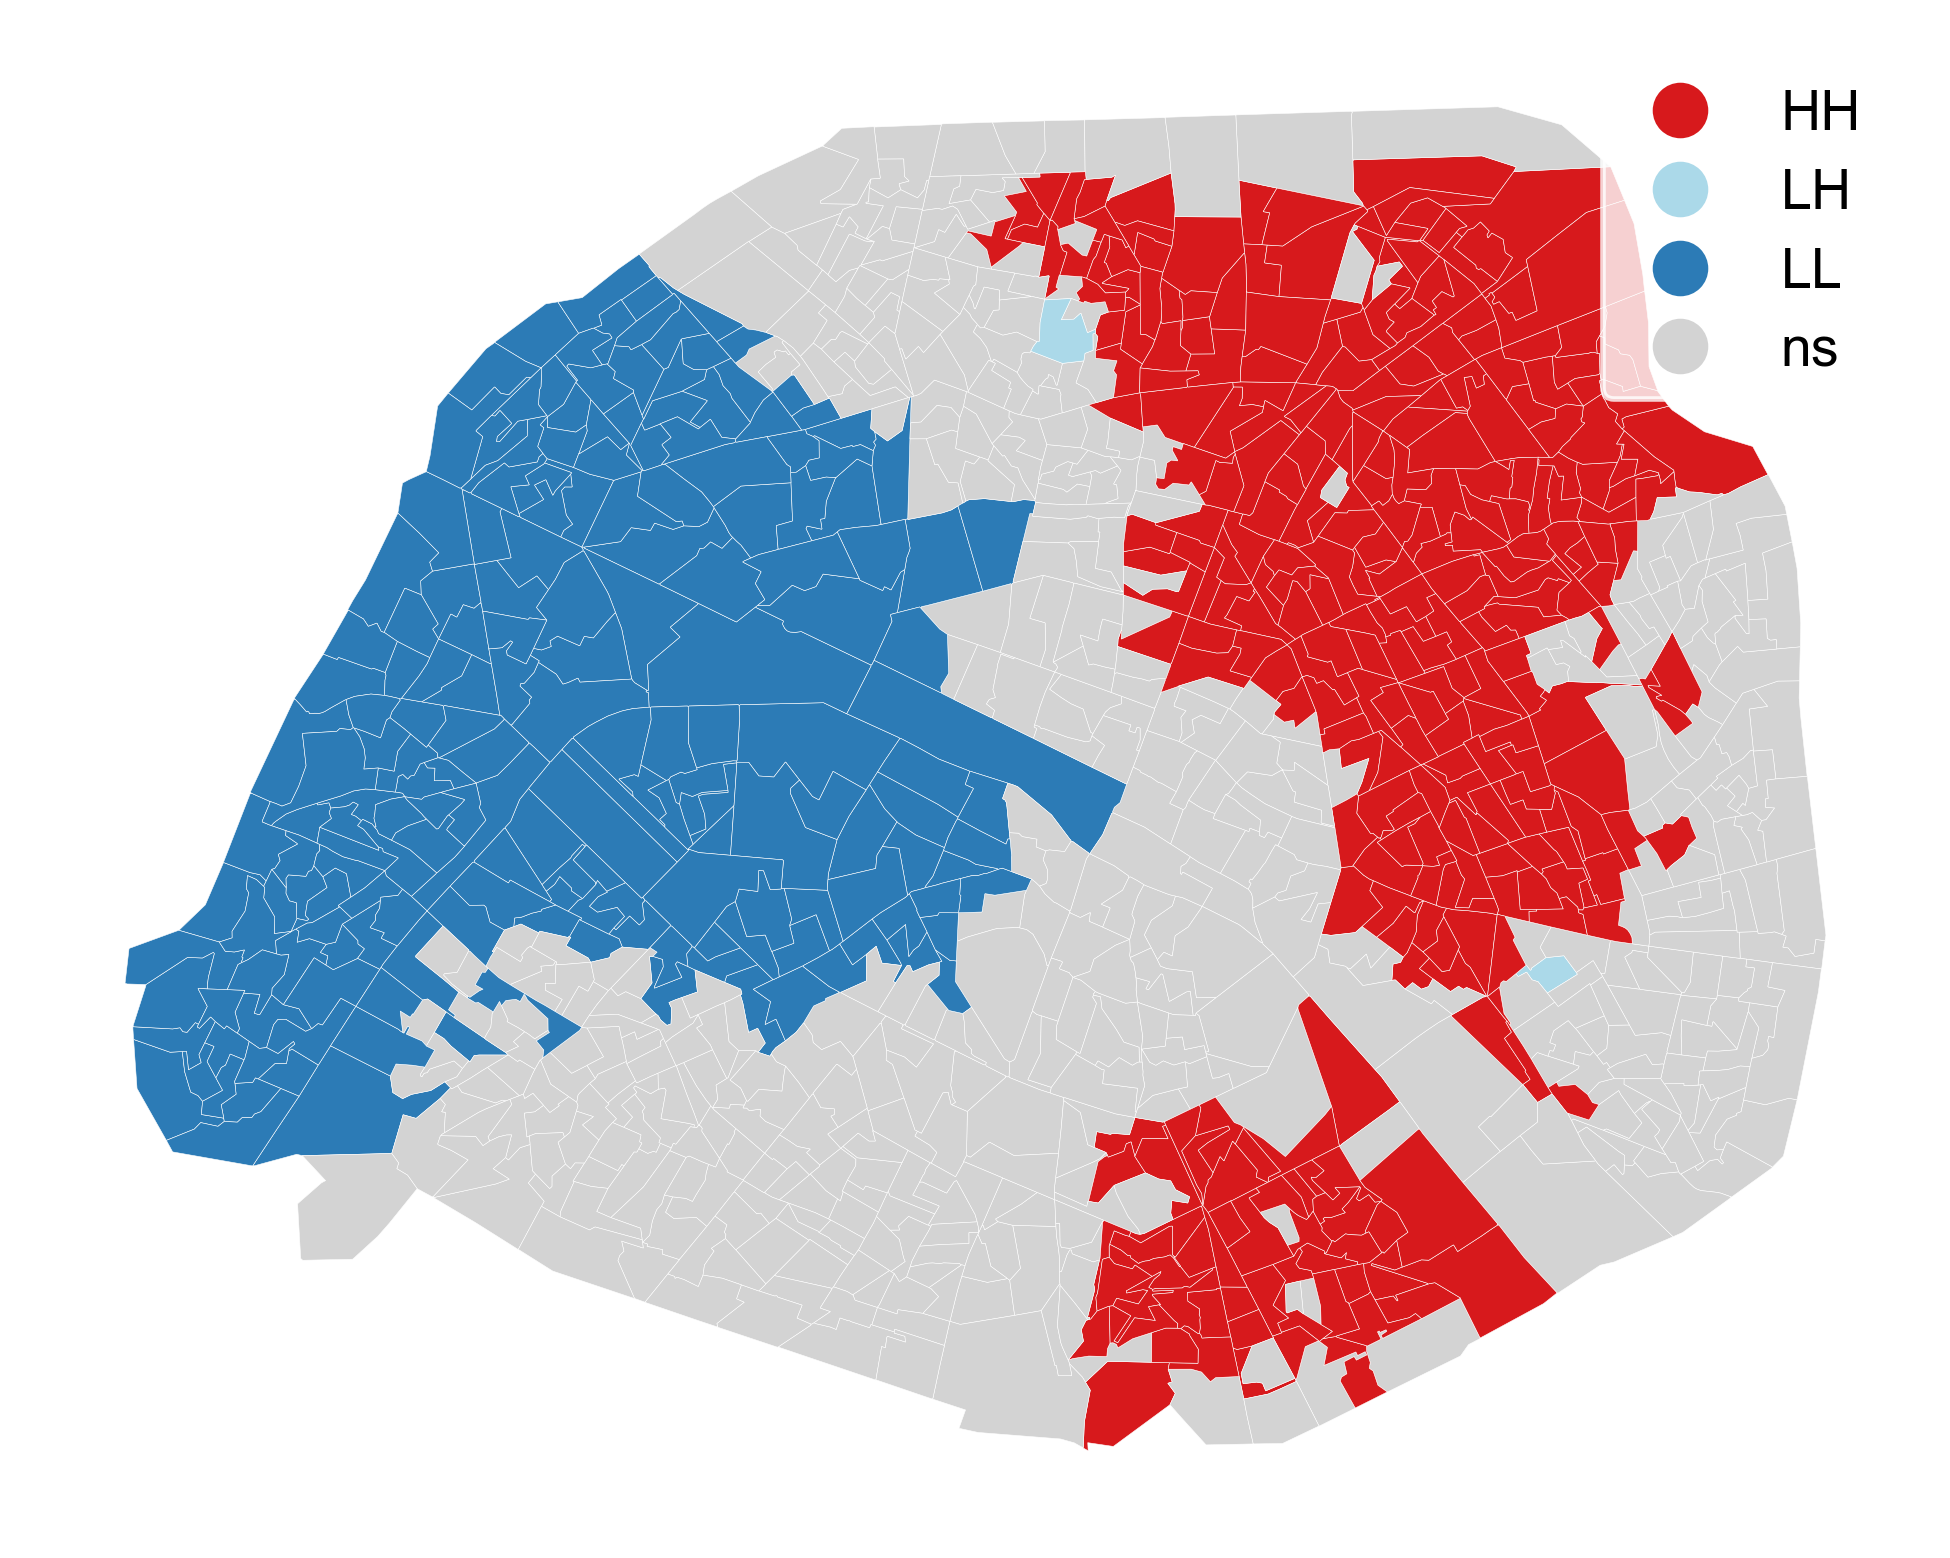

In [9]:
w = weights.Queen.from_dataframe(gdf_vote_sta, use_index=False)
w.transform = "R"
moran = esda.moran.Moran_Local(gdf_vote_sta["LUG_share"], w)
fig = lisa_cluster(moran, gdf_vote_sta)
plt.show()

In [10]:
share = {}
total = gdf_vote_sta["NB_EXPRIM"].sum()
for label in gdf_vote_sta.columns[:9]:
    share[label] = round(100 * (gdf_vote_sta[label].sum() / total), 1)
share

{'LDIV': np.float64(0.0),
 'LDVC': np.float64(1.7),
 'LDVD': np.float64(0.4),
 'LFI': np.float64(1.0),
 'LRN': np.float64(0.0),
 'LUC': np.float64(12.8),
 'LUD': np.float64(36.6),
 'LUG': np.float64(47.3),
 'LVEC': np.float64(0.1)}

In [92]:
gdf_vote_sta_2026 = gpd.read_file(
    "../data/processed/paris_official_data/paris_vote_list_2026.gpkg"
)

In [100]:
share = {}
total = gdf_vote_sta_2026["Votants"].sum()
for label in gdf_vote_sta_2026.columns[8:-12]:
    share[label] = round(100 * (gdf_vote_sta_2026[label].sum() / total), 1)
share

{'LDVG': np.float64(0.1),
 'LEXD': np.float64(2.5),
 'LFI': np.float64(10.9),
 'LDVC': np.float64(0.6),
 'LEXG': np.float64(0.0),
 'LUD': np.float64(35.5),
 'LUC': np.float64(6.1),
 'LUG': np.float64(41.7),
 'LRN': np.float64(0.0),
 'LUXD': np.float64(0.3),
 'LDVD': np.float64(0.3)}

In [11]:
gdf_vote_arr = gpd.read_file(
    "../data/processed/paris_simplified_results/paris_vote_arr_bikenet.gpkg"
)

In [12]:
rm = gdf_vote_arr["LUD_share"].mean()
lm = gdf_vote_arr["LUG_share"].mean()
vote_avg_ratio = rm - lm
gdf_vote_arr["ratio_lr"] = (
    (gdf_vote_arr["LUD"] - gdf_vote_arr["LUG"]) / gdf_vote_arr["NB_EXPRIM"]
) - vote_avg_ratio

In [13]:
vote_avg_ratio

np.float64(-0.06705370037347441)

<Axes: >

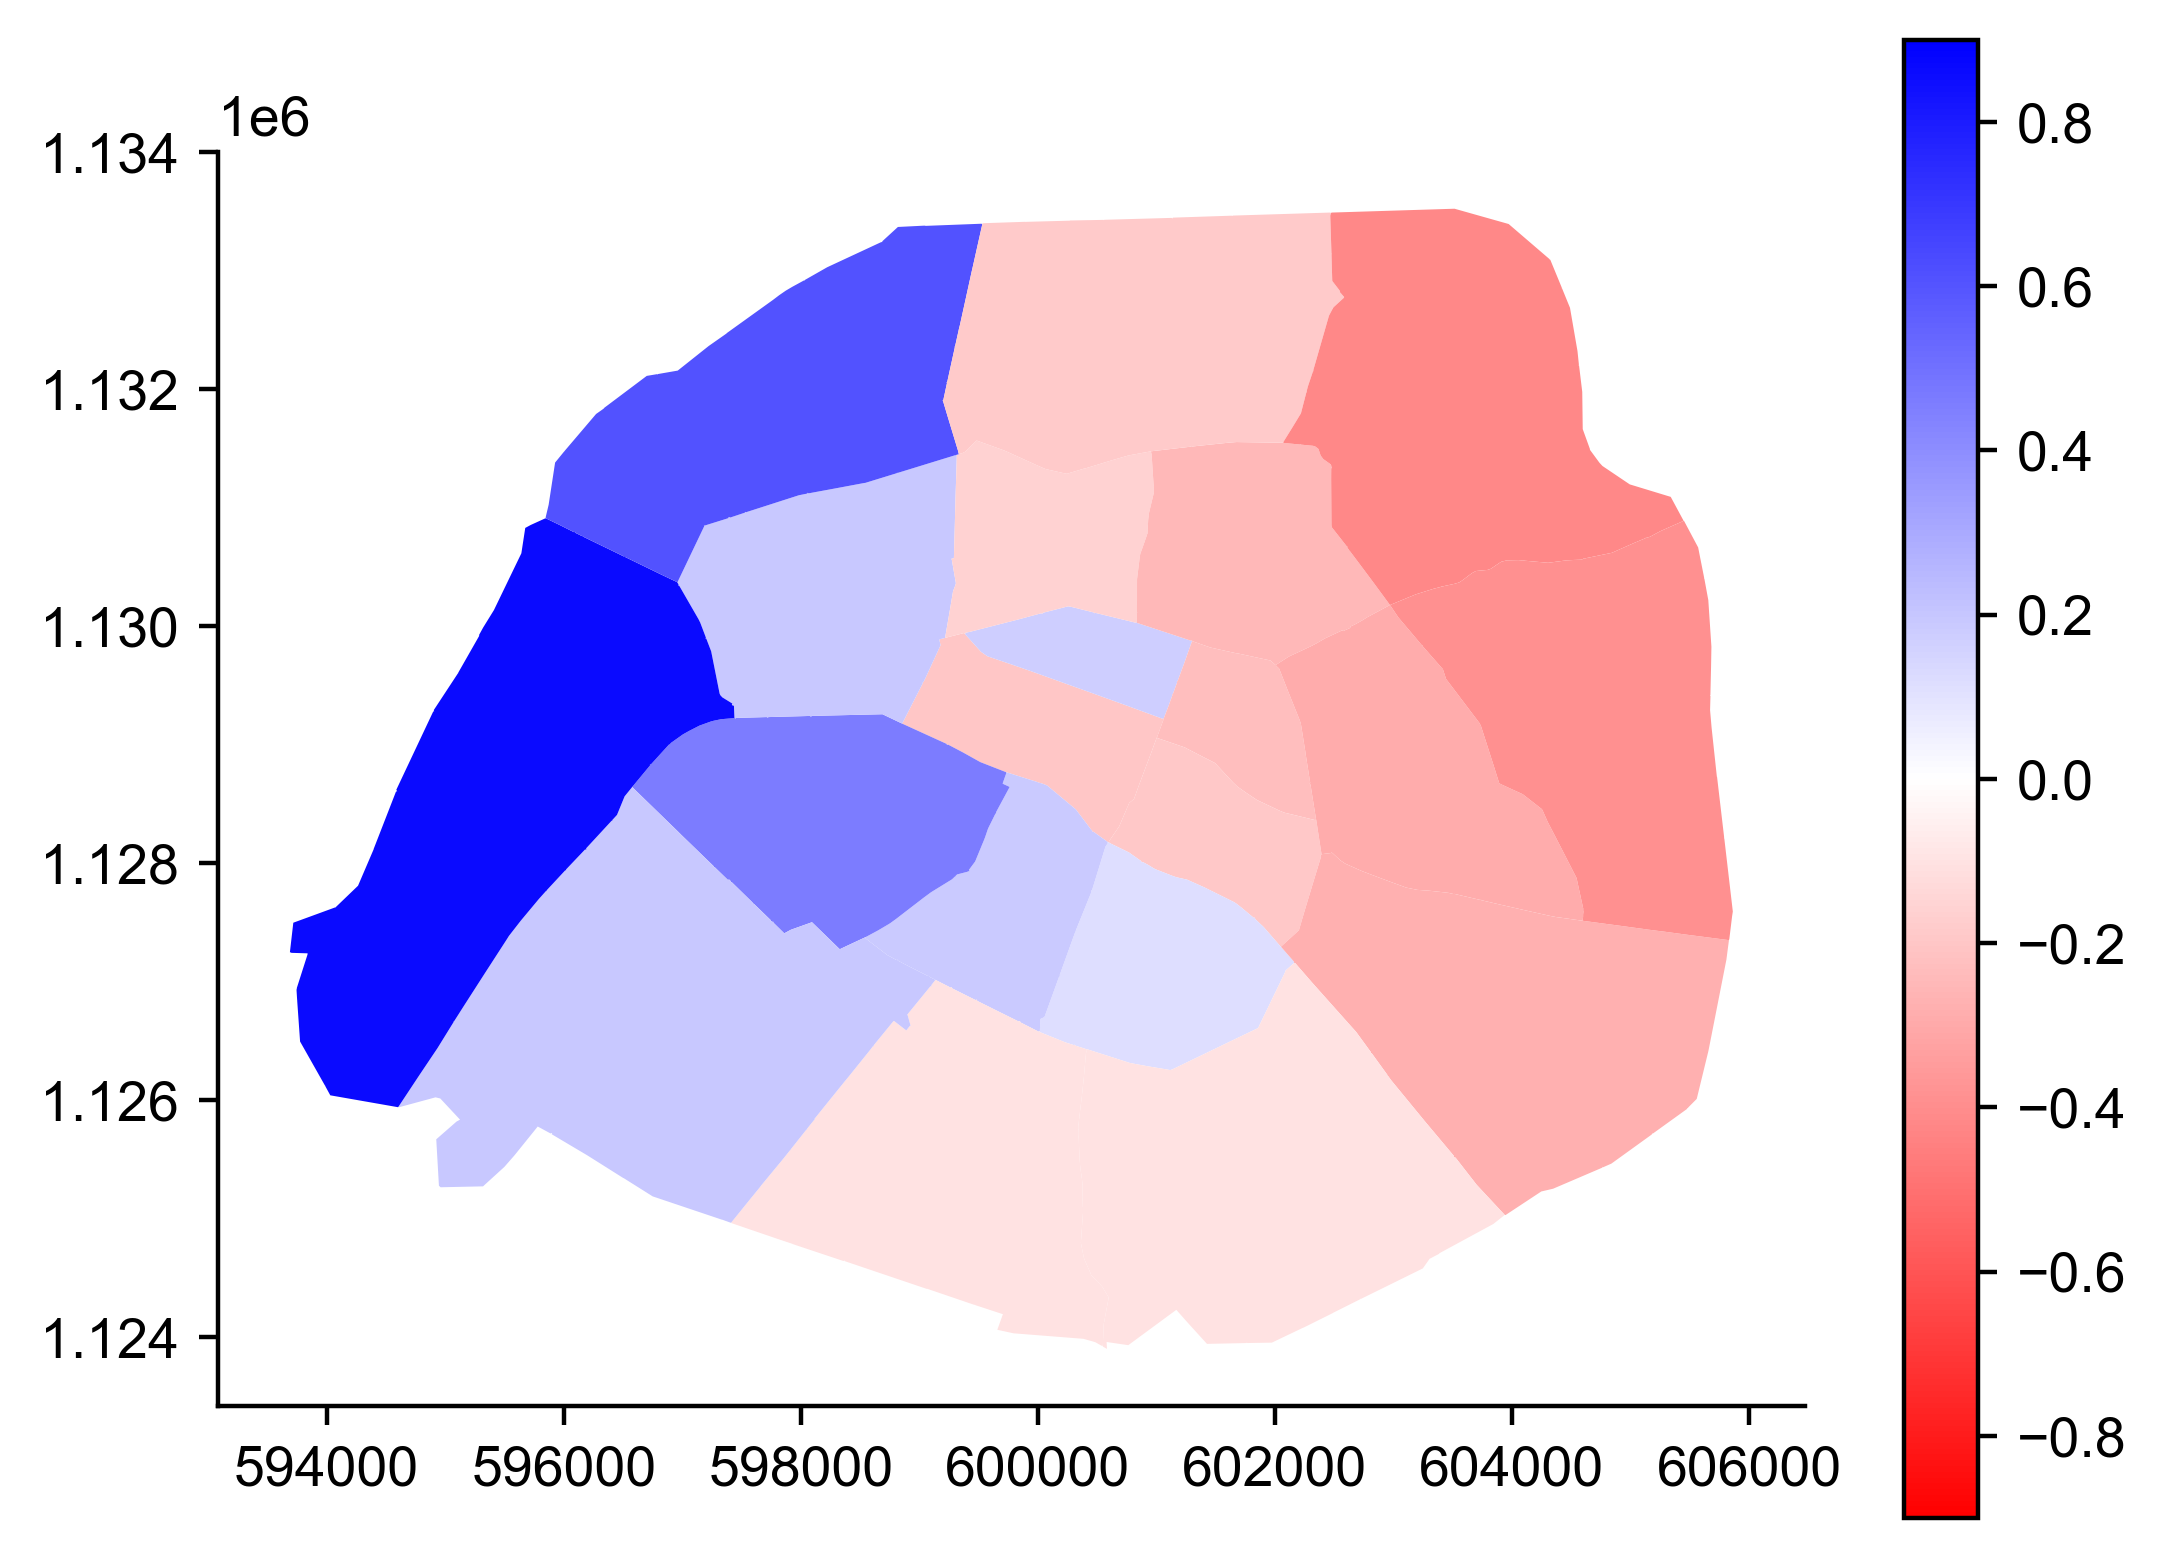

In [14]:
gdf_vote_arr.plot(column="ratio_lr", legend=True, cmap="bwr_r", vmin=-0.9, vmax=0.9)

(-0.4, 0.6)

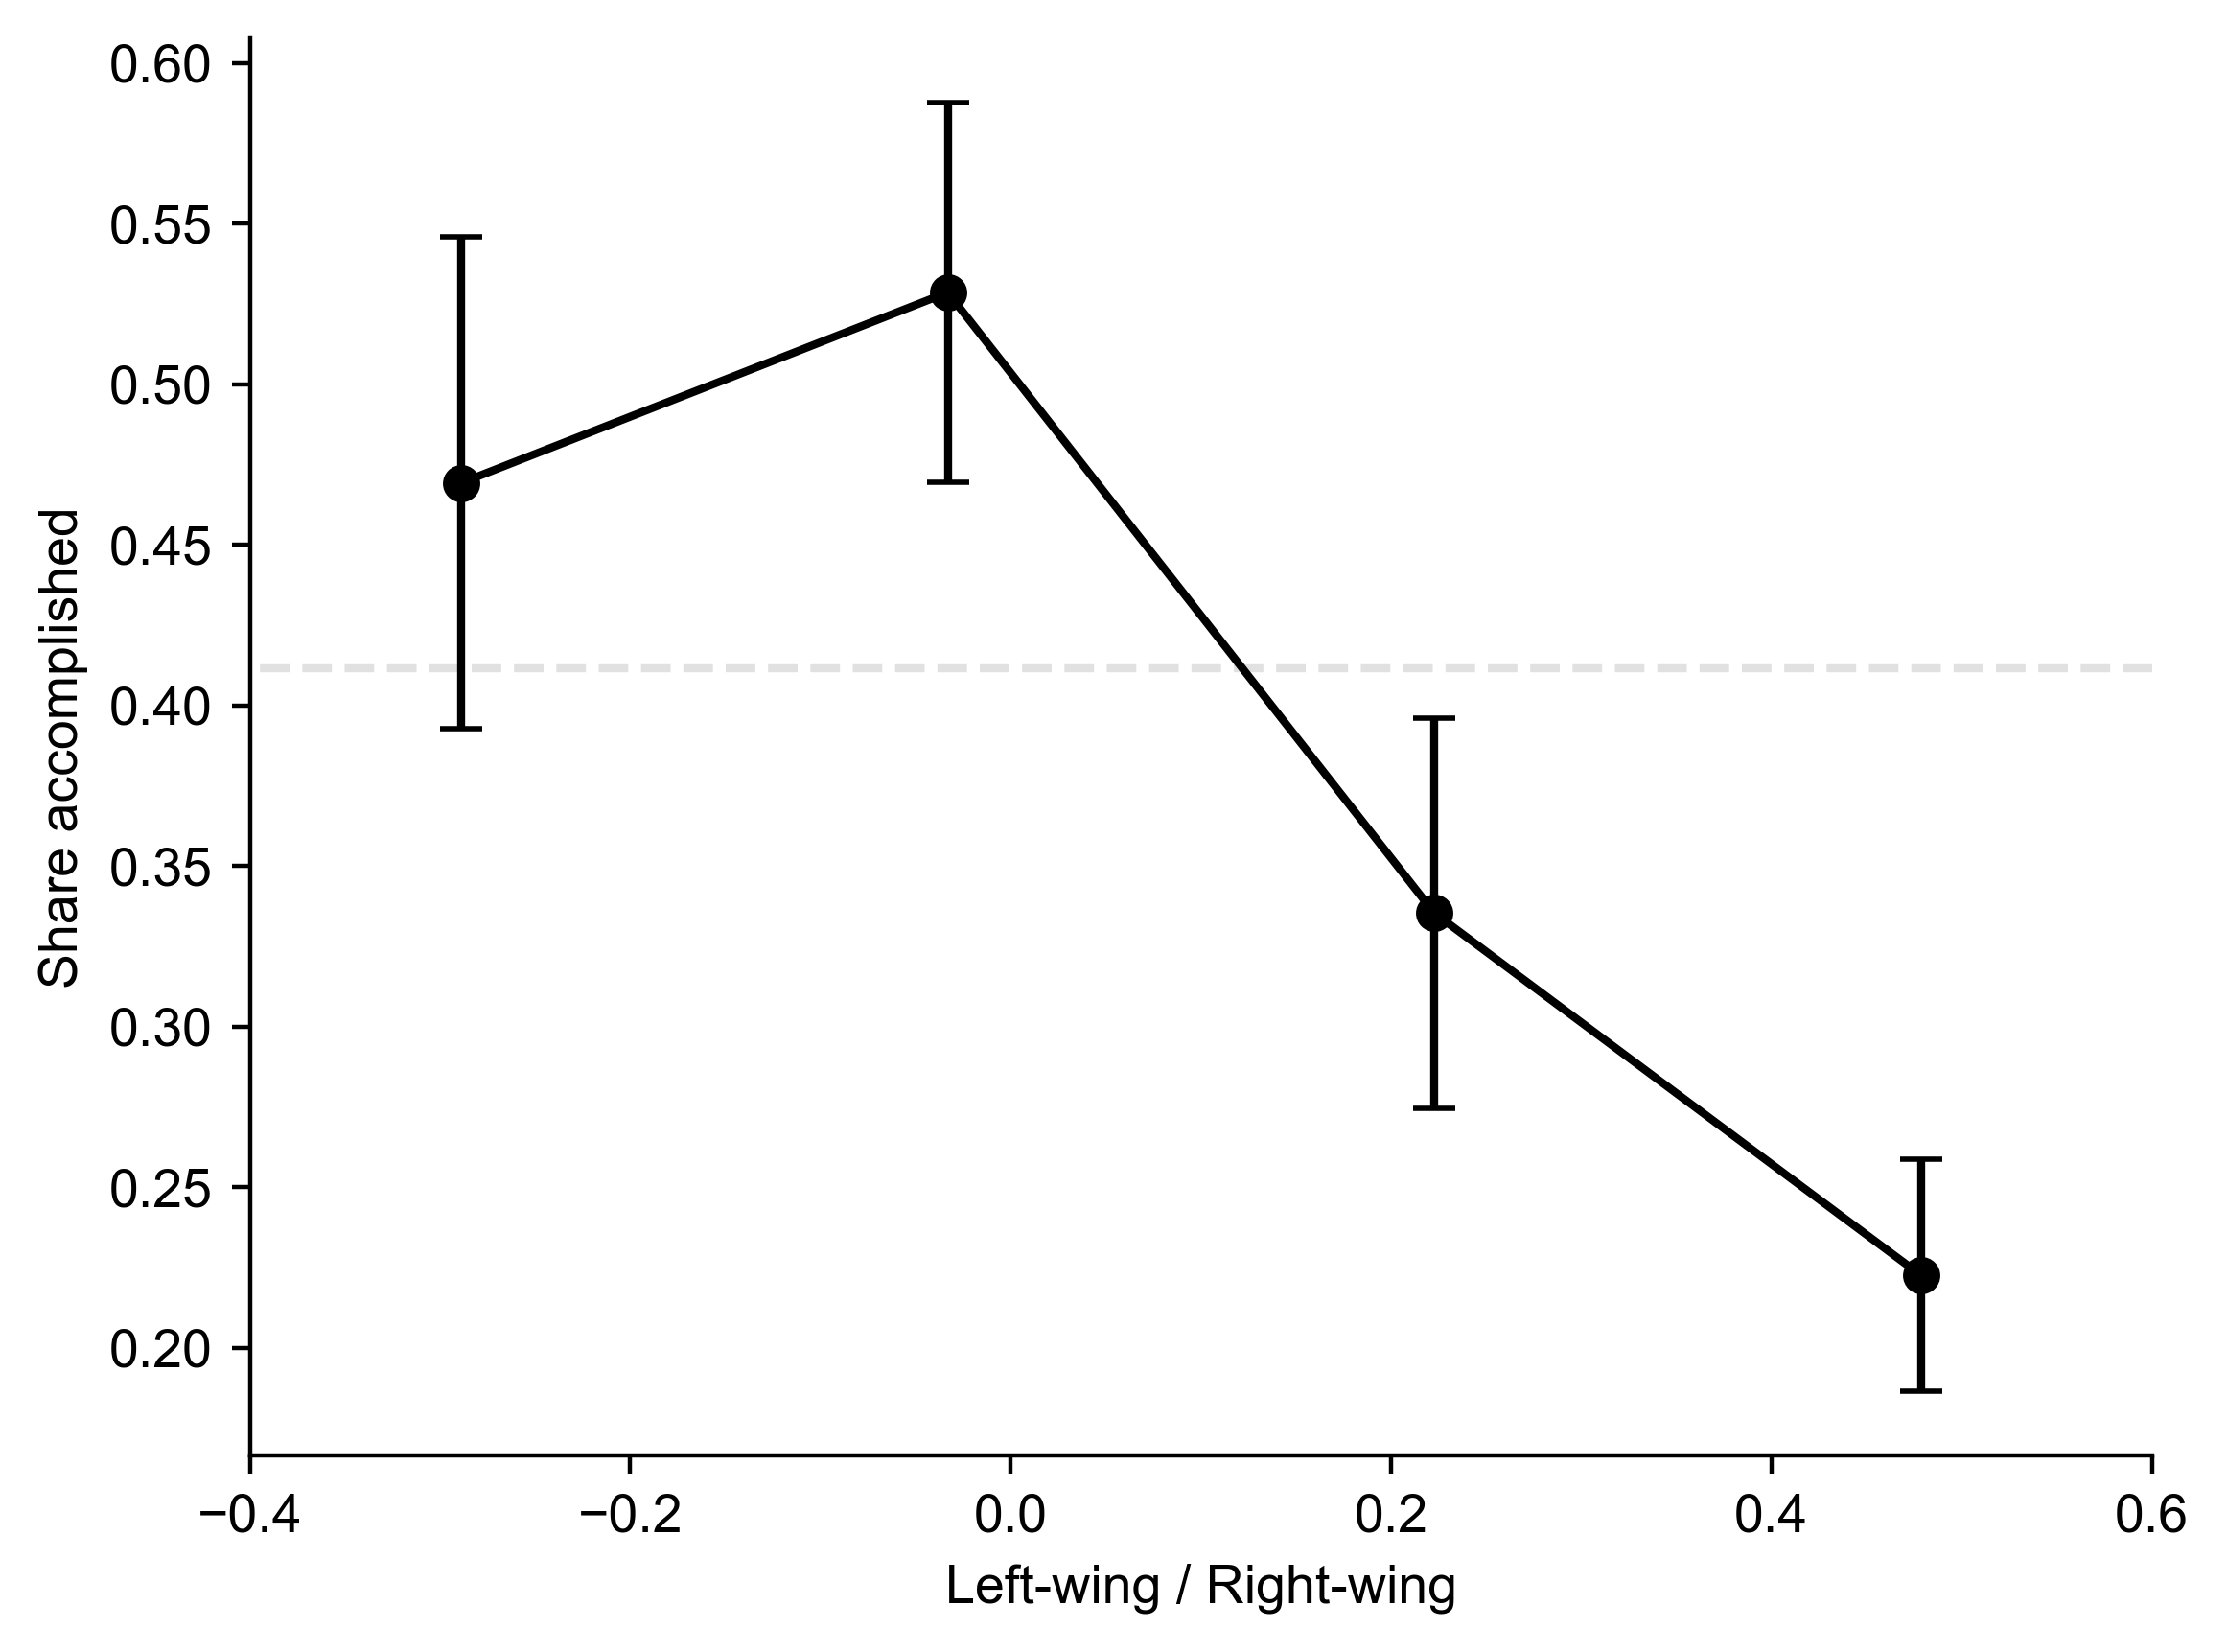

In [15]:
fig, ax = plt.subplots()
mean_acc = gdf_vote_arr["length_accomplished_share"].mean()
bin_edges = np.linspace(
    gdf_vote_arr["ratio_lr"].min(), gdf_vote_arr["ratio_lr"].max(), num=6
)
res = [
    gdf_vote_arr[
        (gdf_vote_arr["ratio_lr"] >= bin_edges[i])
        & (gdf_vote_arr["ratio_lr"] < bin_edges[i + 1])
    ]["length_accomplished_share"].mean()
    for i in range(len(bin_edges) - 1)
]
err = [
    gdf_vote_arr[
        (gdf_vote_arr["ratio_lr"] >= bin_edges[i])
        & (gdf_vote_arr["ratio_lr"] < bin_edges[i + 1])
    ]["length_accomplished_share"].sem()
    for i in range(len(bin_edges) - 1)
]
ax.errorbar(
    [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(len(bin_edges) - 1)],
    res,
    yerr=err,
    marker="o",
    color="black",
)
ax.plot(
    [bin_edges[0], bin_edges[-1]],
    [mean_acc, mean_acc],
    linestyle="dashed",
    color="#E1E1E1",
    zorder=0,
)
ax.set_ylabel("Share accomplished")
ax.set_xlabel("Left-wing / Right-wing")
ax.set_xlim([-0.4, 0.6])

In [16]:
gdf_vote_sta = gpd.read_file(
    "../data/processed/paris_simplified_results/paris_vote_sta_bikenet.gpkg"
)

In [17]:
BINS_ARR = 4
bin_edges = np.linspace(
    min(gdf_vote_sta[["LUG_share", "LUD_share"]].min()),
    max(gdf_vote_sta[["LUG_share", "LUD_share"]].max()),
    num=BINS_ARR + 1,
)
mean_acc = gdf_vote_sta["length_accomplished_share_smoothed"].mean()

In [18]:
SEED = 23
rng = np.random.default_rng(seed=SEED)
SHUFFLE_NUMBER = 100
res_arr_rw = []
res_arr_lw = []
for i in range(SHUFFLE_NUMBER):
    gdf_shuffled = gdf_vote_sta.copy()
    gdf_shuffled["length_accomplished_share_smoothed"] = rng.permutation(
        gdf_shuffled["length_accomplished_share_smoothed"].values
    )
    res_arr_rw.append(
        [
            gdf_shuffled[
                (gdf_shuffled["LUD_share"] >= bin_edges[i])
                & (gdf_shuffled["LUD_share"] < bin_edges[i + 1])
            ]["length_accomplished_share_smoothed"].mean()
            for i in range(len(bin_edges) - 1)
        ]
    )
    res_arr_lw.append(
        [
            gdf_shuffled[
                (gdf_shuffled["LUG_share"] >= bin_edges[i])
                & (gdf_shuffled["LUG_share"] < bin_edges[i + 1])
            ]["length_accomplished_share_smoothed"].mean()
            for i in range(len(bin_edges) - 1)
        ]
    )

(0.12455257271248782, 0.7245525727124877)

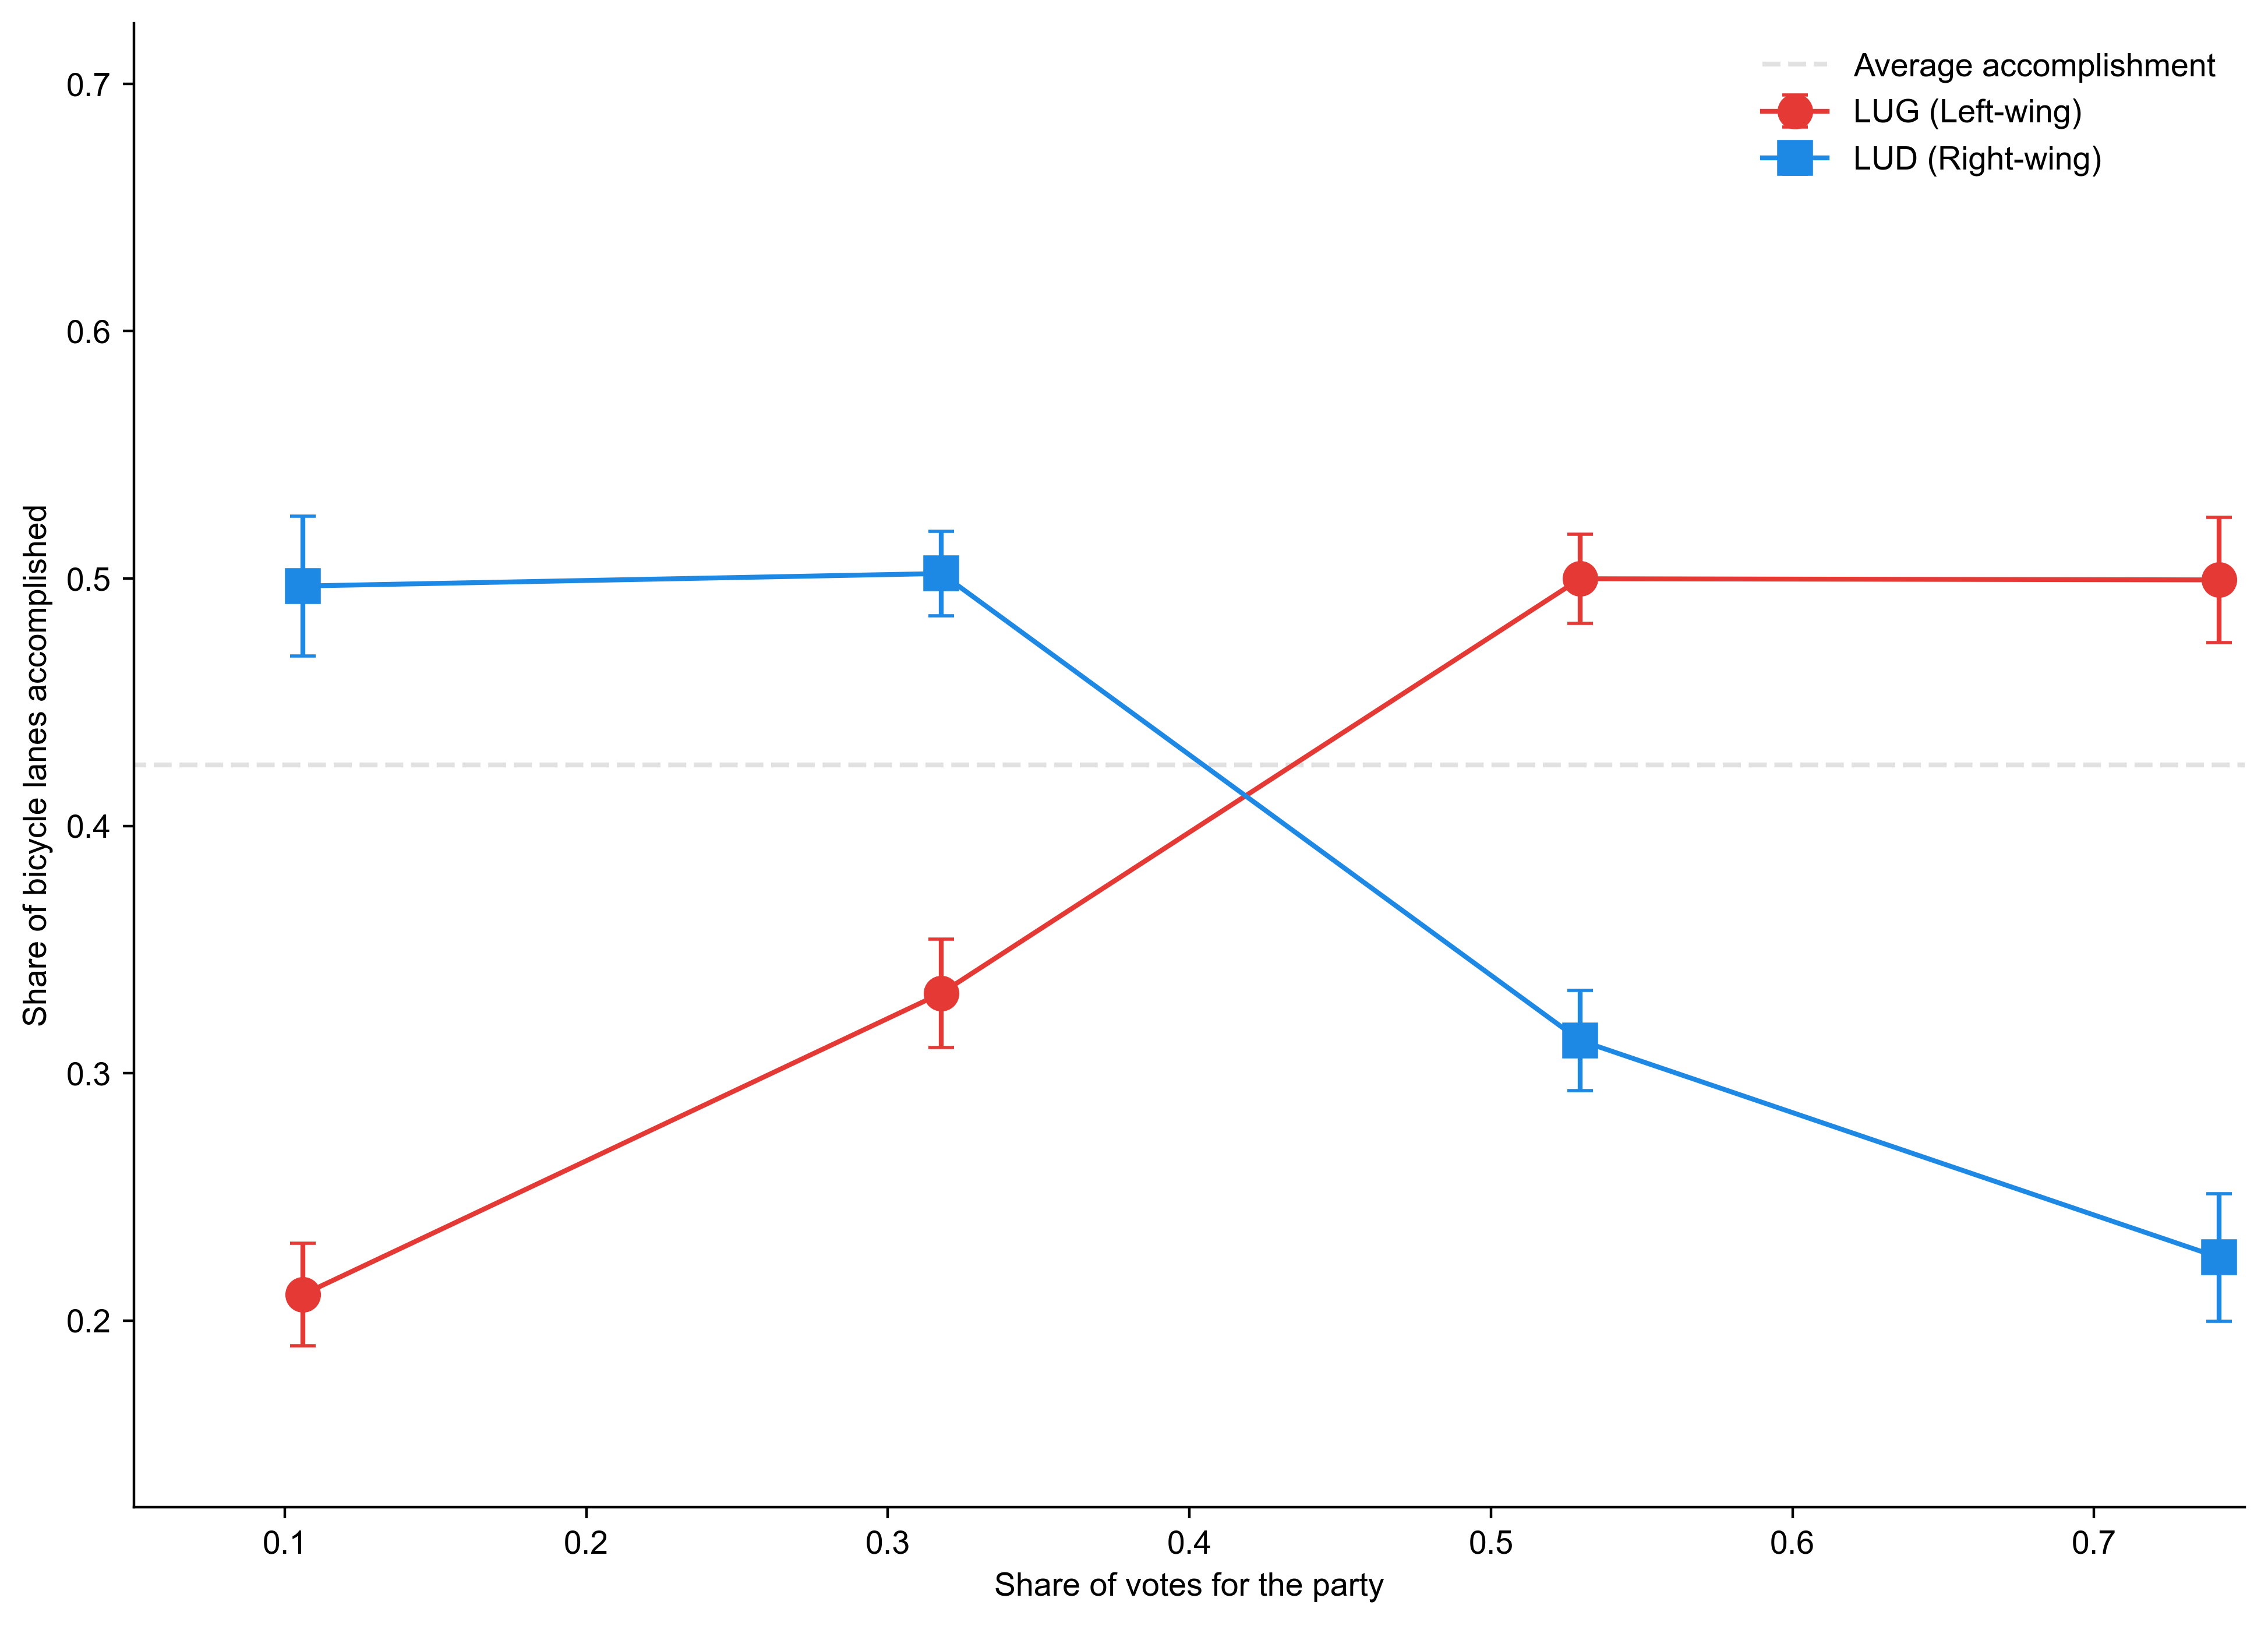

In [21]:
fig, ax = plt.subplots(figsize=plot_params["figsize"])
for ids in range(len(plot_params["party"])):
    res = [
        gdf_vote_sta[
            (gdf_vote_sta[plot_params["party"][ids]] >= bin_edges[i])
            & (gdf_vote_sta[plot_params["party"][ids]] < bin_edges[i + 1])
        ]["length_accomplished_share_smoothed"].mean()
        for i in range(len(bin_edges) - 1)
    ]
    err = [
        gdf_vote_sta[
            (gdf_vote_sta[plot_params["party"][ids]] >= bin_edges[i])
            & (gdf_vote_sta[plot_params["party"][ids]] < bin_edges[i + 1])
        ]["length_accomplished_share_smoothed"].sem()
        for i in range(len(bin_edges) - 1)
    ]
    ax.errorbar(
        [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(len(bin_edges) - 1)],
        res,
        yerr=err,
        **{
            key: val[ids]
            for key, val in plot_params.items()
            if key not in ["figsize", "rcparams", "party", "cmap", "scheme"]
        },
    )
# ax.errorbar(
#     [
#         (bin_edges[i] + bin_edges[i + 1]) / 2
#         for i in range(len(bin_edges) - 1)
#     ],
#     np.mean(res_arr_rw, axis=0),
#     yerr=[np.percentile(res_arr_rw, q=2.5, axis=0), np.percentile(res_arr_rw, q=97.5, axis=0)],
#     color="lightblue",
#     label="reshuffled_LUD"
# )
# ax.errorbar(
#     [
#         (bin_edges[i] + bin_edges[i + 1]) / 2
#         for i in range(len(bin_edges) - 1)
#     ],
#     np.mean(res_arr_lw, axis=0),
#     yerr=[np.percentile(res_arr_lw, q=2.5, axis=0), np.percentile(res_arr_lw, q=97.5, axis=0)],
#     color="firebrick",
#     label="reshuffled_LUG"
# )
yy = [mean_acc, mean_acc]
ax.plot(
    [bin_edges[0], bin_edges[-1]],
    yy,
    linestyle="dashed",
    color="#E1E1E1",
    zorder=0,
    label="Average accomplishment",
)
# TODO add legend modification
ax.legend()
ax.set_xlabel("Share of votes for the party")
ylabel = "Share of bicycle lanes accomplished"
ax.set_ylabel(ylabel)
ax.set_xlim([0.05, 0.75])
ylim = [-0.3, 0.3]
ylim += mean_acc
ax.set_ylim(ylim)

In [22]:
rm = gdf_vote_sta["LUD_share"].mean()
lm = gdf_vote_sta["LUG_share"].mean()
vote_avg_ratio = rm - lm
gdf_vote_sta["ratio_lr"] = (
    (gdf_vote_sta["LUD"] - gdf_vote_sta["LUG"]) / gdf_vote_sta["NB_EXPRIM"]
) - vote_avg_ratio

(np.float64(593080.1149415328),
 np.float64(606472.1311147512),
 np.float64(1123422.6887695687),
 np.float64(1134004.674048429))

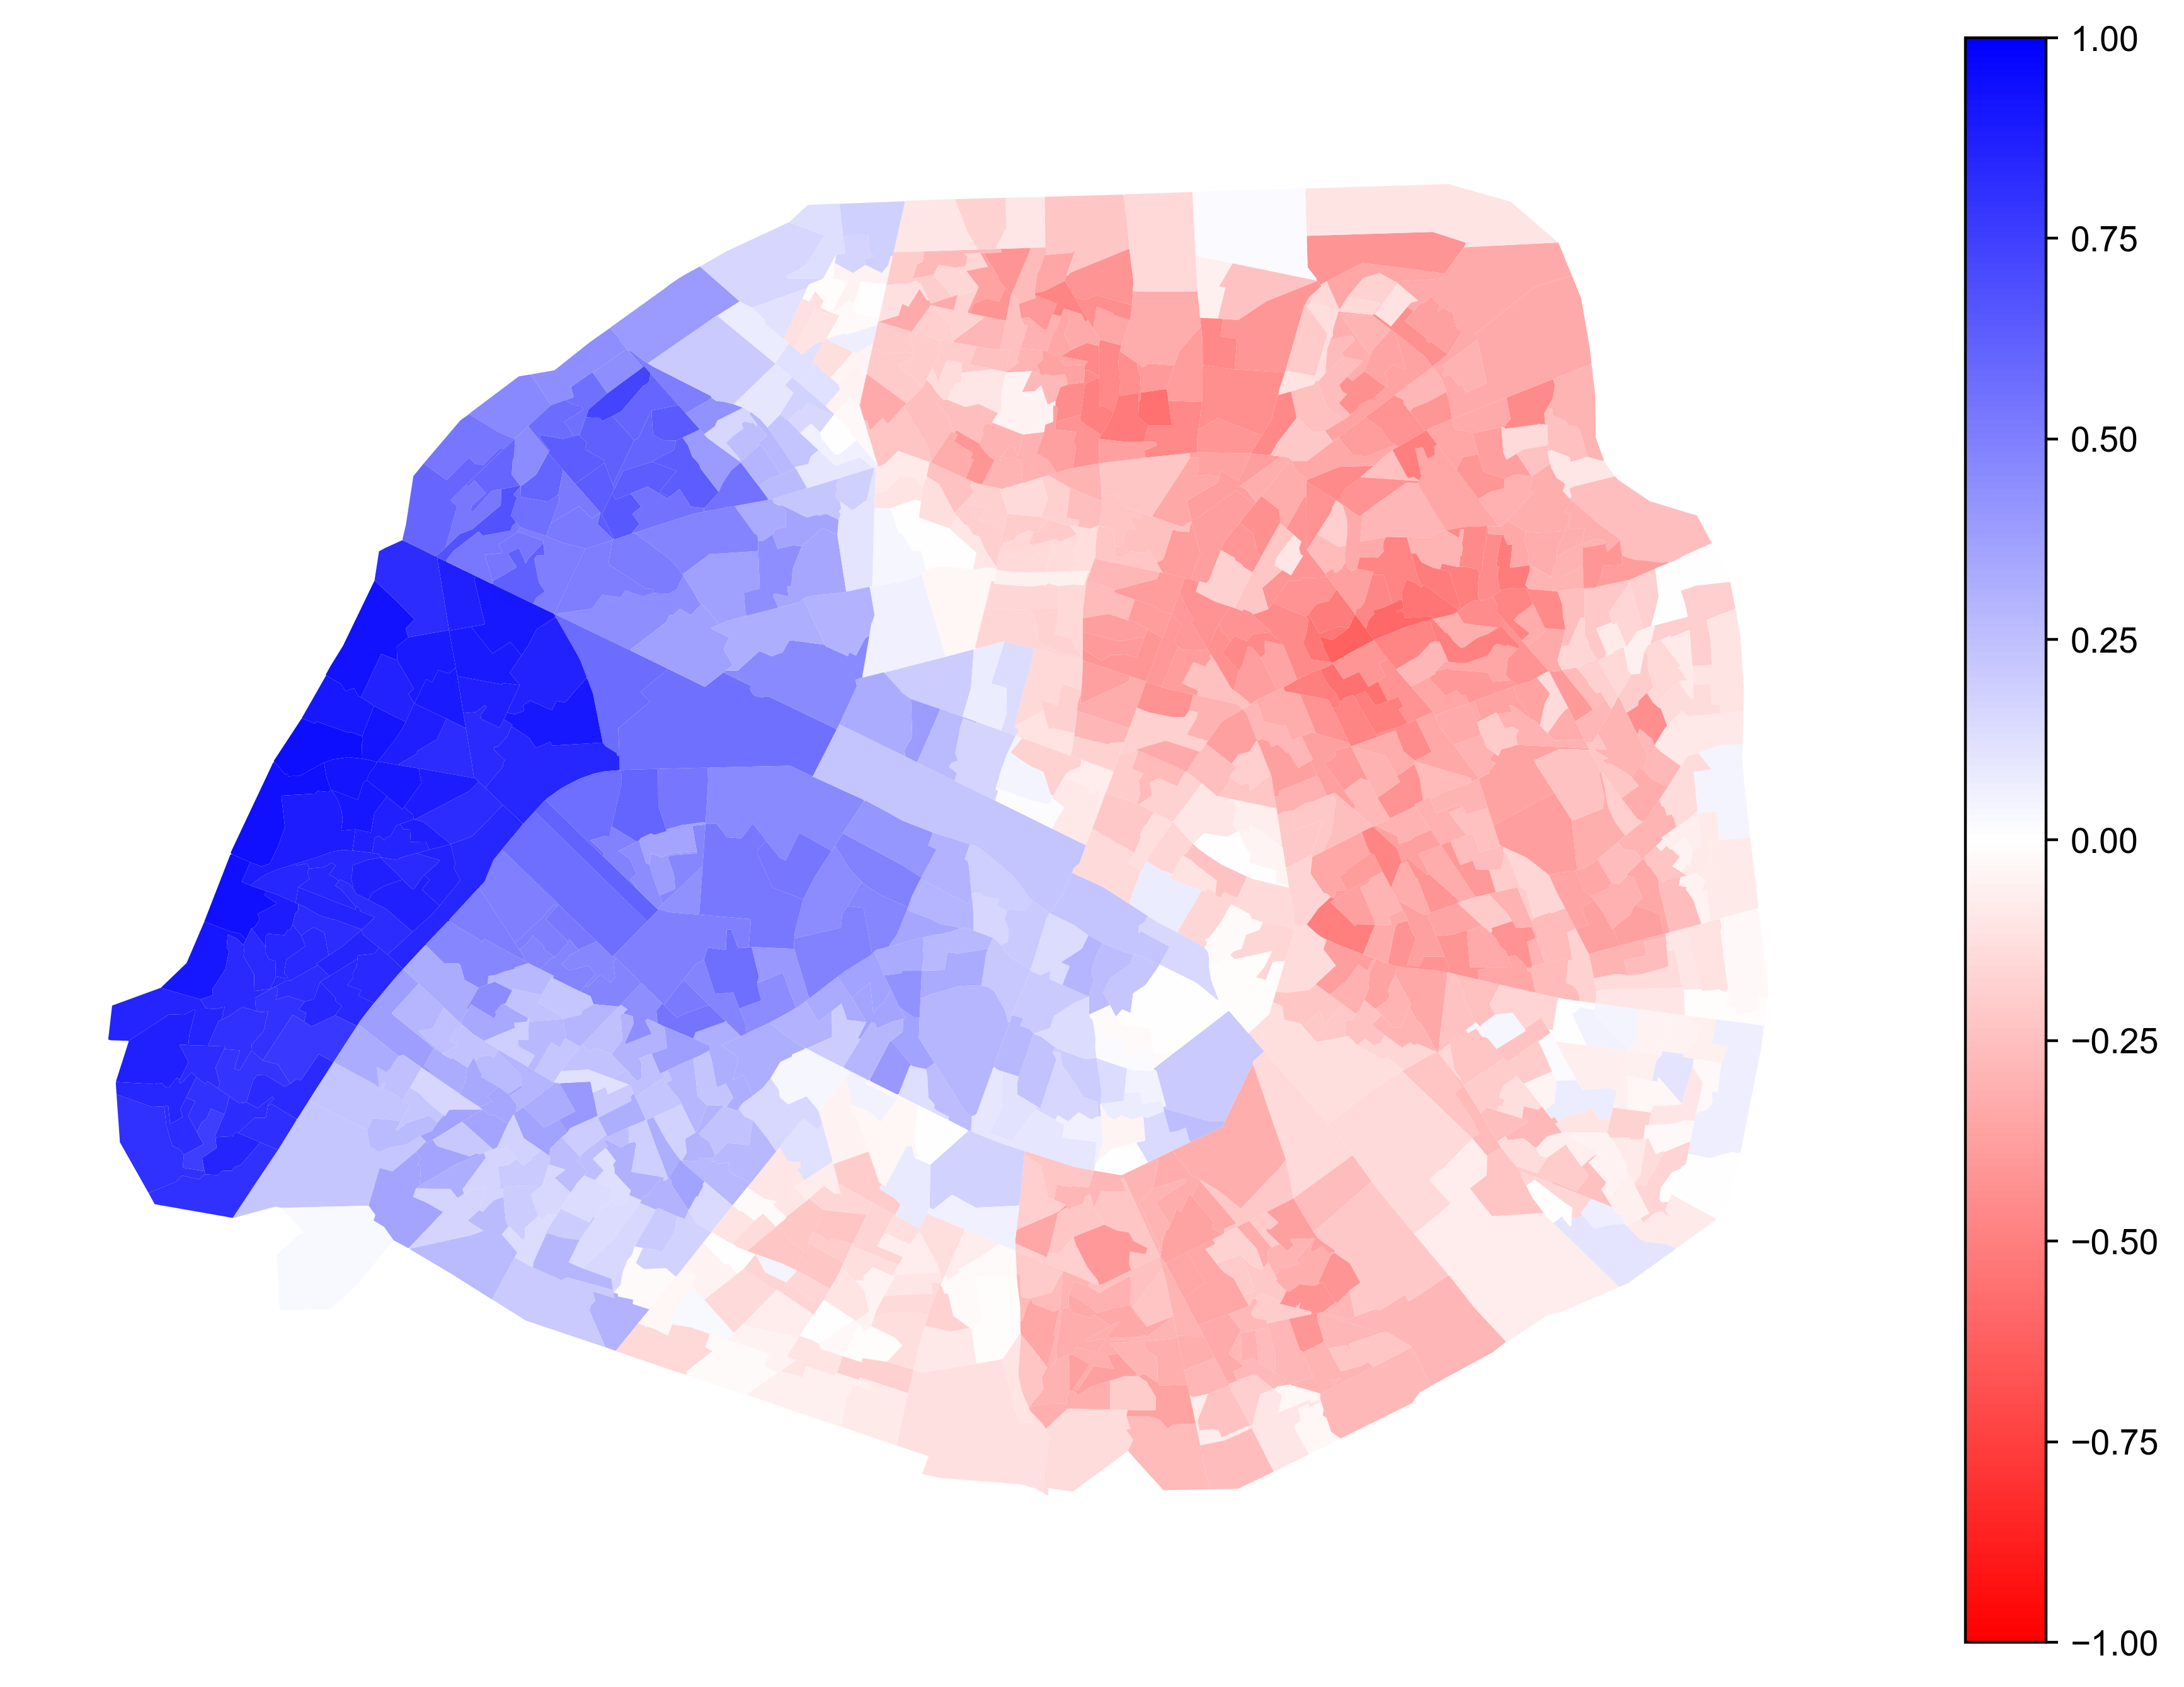

In [23]:
fig, ax = plt.subplots(figsize=plot_params["figsize"])
gdf_vote_sta.plot(column="ratio_lr", legend=True, cmap="bwr_r", vmin=-1, vmax=1, ax=ax)
ax.axis("off")

(-0.9, 0.9)

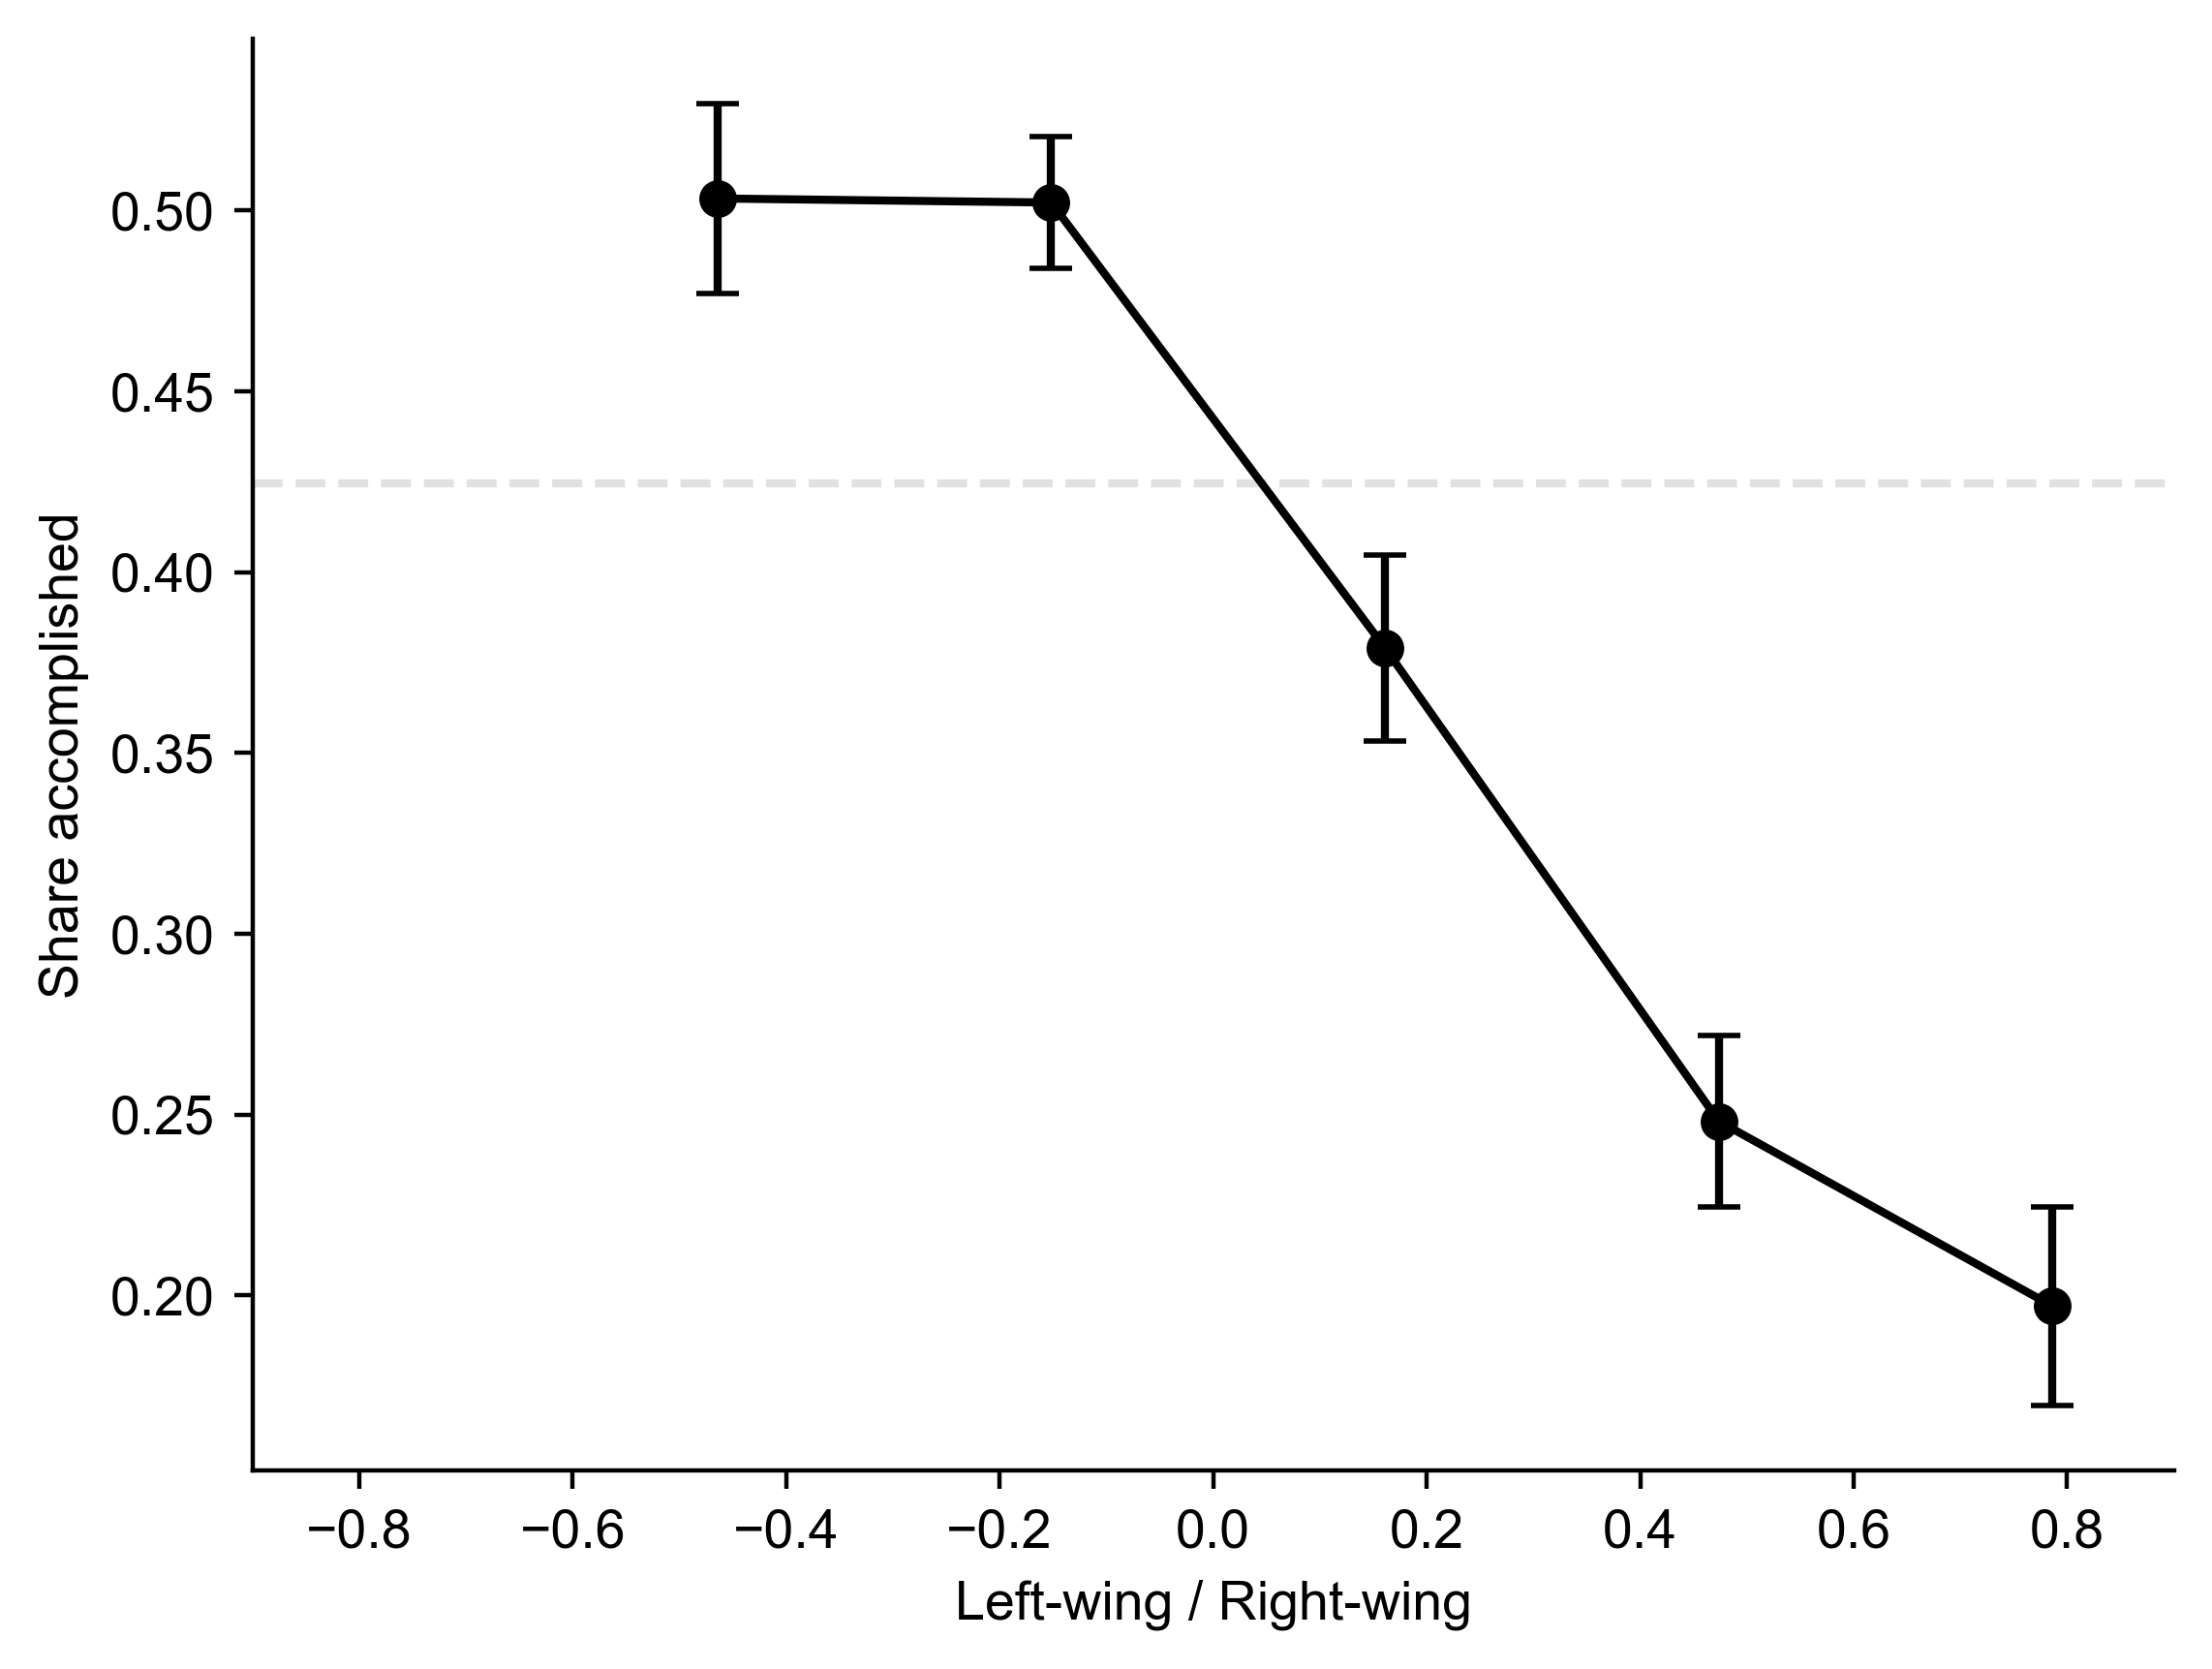

In [24]:
fig, ax = plt.subplots()
mean_acc = gdf_vote_sta["length_accomplished_share_smoothed"].mean()
bin_edges = np.linspace(
    gdf_vote_sta["ratio_lr"].min(), gdf_vote_sta["ratio_lr"].max(), num=6
)
res = [
    gdf_vote_sta[
        (gdf_vote_sta["ratio_lr"] >= bin_edges[i])
        & (gdf_vote_sta["ratio_lr"] < bin_edges[i + 1])
    ]["length_accomplished_share_smoothed"].mean()
    for i in range(len(bin_edges) - 1)
]
err = [
    gdf_vote_sta[
        (gdf_vote_sta["ratio_lr"] >= bin_edges[i])
        & (gdf_vote_sta["ratio_lr"] < bin_edges[i + 1])
    ]["length_accomplished_share_smoothed"].sem()
    for i in range(len(bin_edges) - 1)
]
ax.errorbar(
    [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(len(bin_edges) - 1)],
    res,
    yerr=err,
    marker="o",
    color="black",
)
ax.plot(
    [-0.9, 0.9],
    [mean_acc, mean_acc],
    linestyle="dashed",
    color="#E1E1E1",
    zorder=0,
)
ax.set_ylabel("Share accomplished")
ax.set_xlabel("Left-wing / Right-wing")
ax.set_xlim([-0.9, 0.9])

In [25]:
model = sm.OLS(
    gdf_vote_sta["length_accomplished_share_smoothed"],
    sm.add_constant(gdf_vote_sta["ratio_lr"].values),
).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    OLS Regression Results                                    
==============================================================================================
Dep. Variable:     length_accomplished_share_smoothed   R-squared:                       0.096
Model:                                            OLS   Adj. R-squared:                  0.095
Method:                                 Least Squares   F-statistic:                     95.12
Date:                                Mon, 13 Apr 2026   Prob (F-statistic):           2.00e-21
Time:                                        15:27:10   Log-Likelihood:                -275.50
No. Observations:                                 897   AIC:                             555.0
Df Residuals:                                     895   BIC:                             564.6
Df Model:                                           1                                         
Covariance Type:                            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4246      0.011     38.610      0.000       0.403       0.446
x1            -0.2843      0.029     -9.753      0.000      -0.342      -0.227
==============================================================================
Omnibus:                      794.602   Durbin-Watson:                   1.952
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               62.051
Skew:                           0.201   Prob(JB):                     3.36e-14
Kurtosis:                       1.776   Cond. No.                         2.65
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Text(0.5, 0, 'Left-wing / Right-wing')

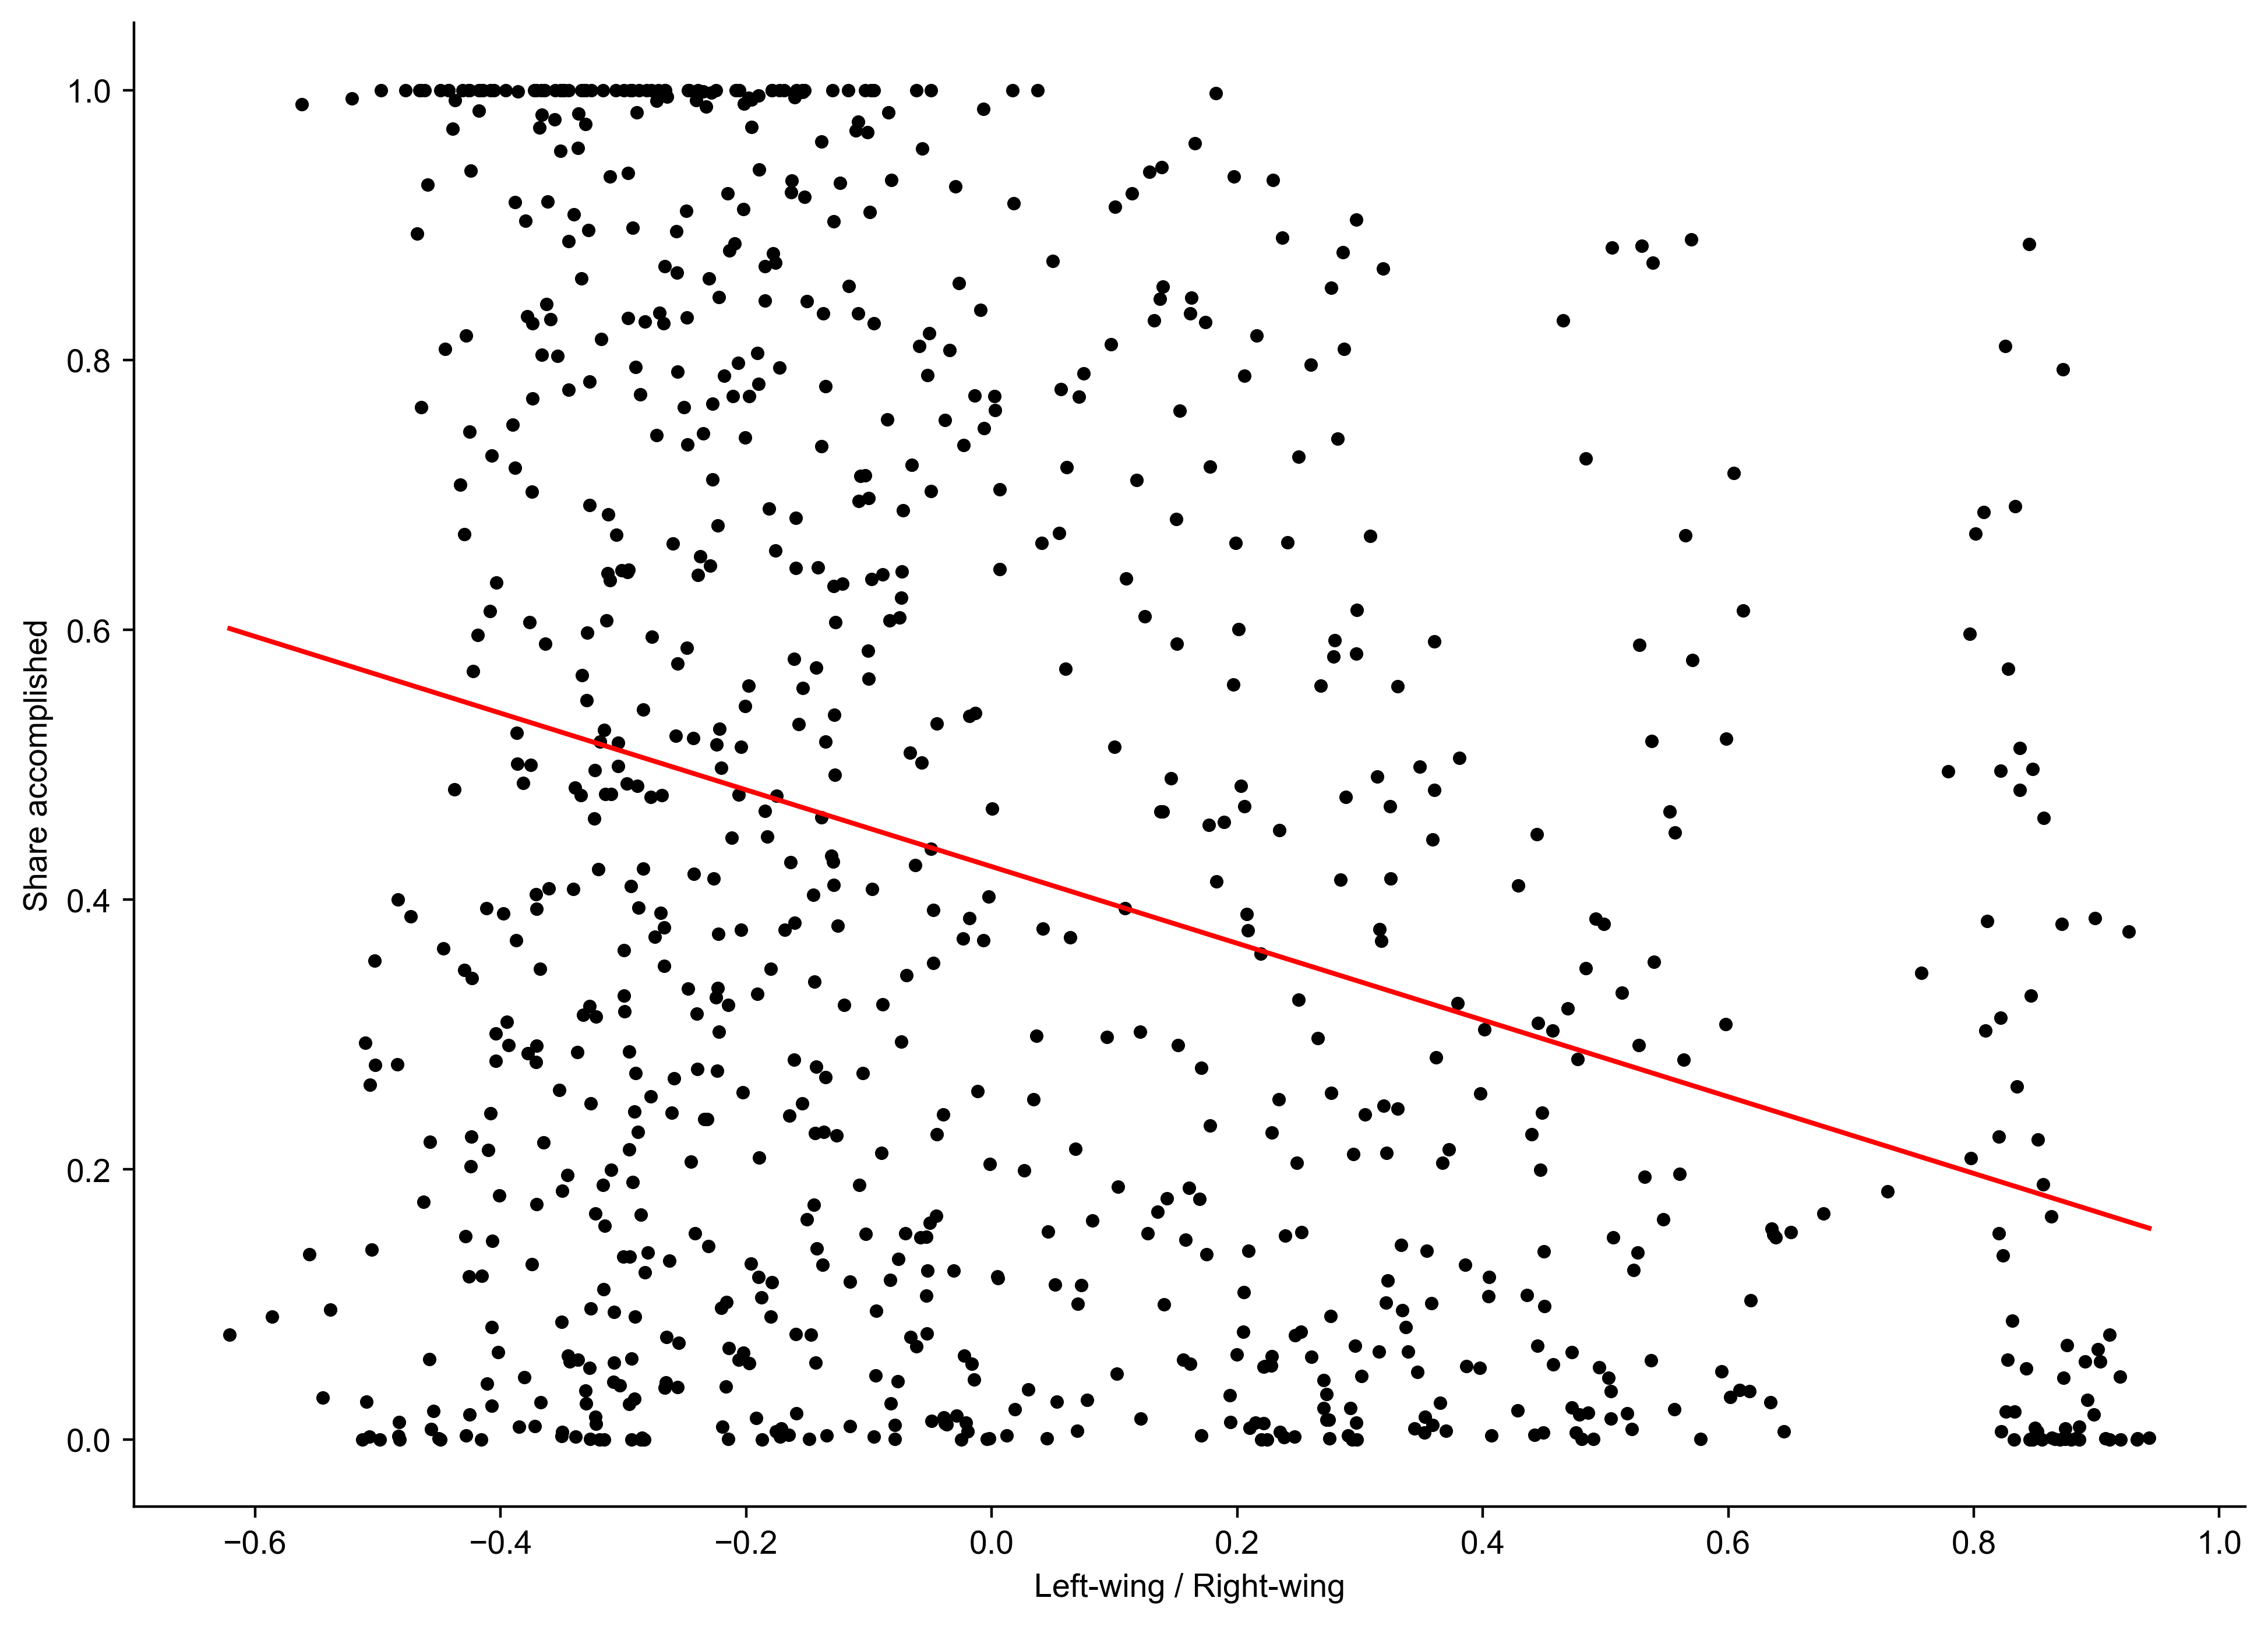

In [26]:
fig, ax = plt.subplots(figsize=plot_params["figsize"])
ax.scatter(
    gdf_vote_sta["ratio_lr"],
    gdf_vote_sta["length_accomplished_share_smoothed"],
    color="black",
    s=10,
)
xx = np.linspace(
    gdf_vote_sta["ratio_lr"].min(), gdf_vote_sta["ratio_lr"].max(), num=100
)
ax.plot(xx, model.params["x1"] * xx + model.params["const"], color="red")
ax.set_ylabel("Share accomplished")
ax.set_xlabel("Left-wing / Right-wing")